In [5]:
import pandas as pd
import numpy as np
from scipy.special import expit, logsumexp
import time


def log_likelihood(beta, X, y):
    logits = X @ beta
    ll = np.sum(y * logits - np.log1p(np.exp(logits)))
    return ll

def grad_log_likelihood(beta, X, y):
    probs = expit(X @ beta)
    return X.T @ (y - probs)

def log_prior(beta, prior_var=10.0):
    d = len(beta)
    const = - (d / 2.0) * np.log(2 * np.pi * prior_var)
    return const - (1.0 / (2 * prior_var)) * np.sum(beta**2)

def grad_log_prior(beta, prior_var=10.0):
    """计算对数先验的梯度"""
    return - beta / prior_var


def hmc_transition_step(beta_current, t, epsilon, L, X, y, prior_var=10.0):
    d = len(beta_current)
    p_current = np.random.normal(0, 1, size=d)
    
    beta = beta_current.copy()
    p = p_current.copy()
    
    def get_grad_U(b):
        return -(grad_log_prior(b, prior_var) + t * grad_log_likelihood(b, X, y))
    
    grad_U = get_grad_U(beta)
    p = p - 0.5 * epsilon * grad_U
    
    for i in range(L):
        beta = beta + epsilon * p
        grad_U = get_grad_U(beta)
        if i != L - 1:
            p = p - epsilon * grad_U
            
    p = p - 0.5 * epsilon * grad_U
    p = -p  
    
    U_current = -(log_prior(beta_current, prior_var) + t * log_likelihood(beta_current, X, y))
    K_current = 0.5 * np.sum(p_current**2)
    
    U_proposed = -(log_prior(beta, prior_var) + t * log_likelihood(beta, X, y))
    K_proposed = 0.5 * np.sum(p**2)
    
    energy_diff = (U_current + K_current) - (U_proposed + K_proposed)
    alpha = np.exp(np.clip(energy_diff, -100, 0)) 
    
    if np.random.rand() < alpha:
        return beta, 1  
    else:
        return beta_current, 0  


# AIS-HMC 退火重要性采样主积分算法
def run_ais_hmc(X, y, num_chains, num_steps, epsilon, L, prior_var=10.0):
    d = X.shape[1]
    temperatures = np.linspace(0, 1, num_steps)
    
    log_weights = np.zeros(num_chains)
    
    # 记录动态阶段接受率的变量
    phase_accepts = np.zeros(3)
    phase_transitions = np.zeros(3)
    
    # 热力学积分的期望累加器
    ti_mean_log_likelihood = np.zeros(num_steps)
    
    start_time = time.time()
    print(f"\nAIS-HMC 积分 | 维度: {d} | 链数: {num_chains} | 温度层: {num_steps}")
    
    for chain in range(num_chains):
        beta = np.random.normal(0, np.sqrt(prior_var), size=d)
        
        for k in range(1, num_steps):
            t_prev = temperatures[k-1]
            t_curr = temperatures[k]
            
            current_log_lik = log_likelihood(beta, X, y)
            
            log_weights[chain] += (t_curr - t_prev) * current_log_lik
            
            ti_mean_log_likelihood[k] += current_log_lik
            
            beta, accepted = hmc_transition_step(beta, t_curr, epsilon, L, X, y, prior_var)
            
            if t_curr < 0.33:
                phase = 0
            elif t_curr < 0.67:
                phase = 1
            else:
                phase = 2
            phase_accepts[phase] += accepted
            phase_transitions[phase] += 1
            
        if (chain + 1) % max(1, num_chains // 5) == 0:
            print(f"   [+] 已完成退火链: {chain + 1}/{num_chains}")

    runtime = time.time() - start_time
    
    # 对数边际似然 log p(y) 与 标准误 SE
    log_marginal_likelihood = logsumexp(log_weights) - np.log(num_chains)
    weights_normalized = np.exp(log_weights - log_marginal_likelihood) / num_chains
    se_log_Z = np.sqrt(np.var(weights_normalized * num_chains) / num_chains)
    
    # 有效样本数 ESS
    log_ess = 2 * logsumexp(log_weights) - logsumexp(2 * log_weights)
    ess = np.exp(log_ess)
    
    # 对数权重方差 Var(log W) (KL 散度估计)
    var_log_w = np.var(log_weights)
    
    # 热力学积分交叉验证值 (TI Estimate)
    ti_mean_log_likelihood /= num_chains
    delta_t = 1.0 / (num_steps - 1)
    ti_estimate = np.sum(ti_mean_log_likelihood[1:] * delta_t)
    
    # 动态阶段接受率
    phase_rates = (phase_accepts / phase_transitions) * 100

    print(f"[运行耗时 Runtime]: {runtime:.2f} 秒")
    print(f"[AIS 边际似然估计 log p(y)] : {log_marginal_likelihood:.4f}  (SE: ±{se_log_Z:.4f})")
    print(f"[TI  热力学积分交叉验证值] : {ti_estimate:.4f}  (与AIS越近越稳健)")
    print(f"[权重退化诊断 ESS]         : {ess:.2f} / {num_chains} 条链")
    print(f"[对数权重方差 Var(log W)]  : {var_log_w:.4f}  (反映信息拓扑距离)")
    print(f"[动态阶段接受率衰减曲线]   :")
    print(f"   ├── T < 0.3 (先验开阔期): {phase_rates[0]:.2f}%")
    print(f"   ├── T 0.3~0.7 (空间压缩期): {phase_rates[1]:.2f}%")
    print(f"   └── T > 0.7 (后验窄脊期): {phase_rates[2]:.2f}%")
    
    return log_marginal_likelihood, runtime, ess, var_log_w, phase_rates, ti_mean_log_likelihood



def load_and_split_data(csv_file_path):
    df = pd.read_csv(csv_file_path)
    y = df['y'].values
    X = df.drop(columns=['y']).values
    return X, y

# =========================================================================
# 4. 数据加载驱动层与多维场景评测主入口 (已修正变量接收)
# =========================================================================

if __name__ == "__main__":

    print("低维后验场景 (Pima Diabetes)")
    X_pima, y_pima = load_and_split_data("pima_preprocessed_低维.csv")
    
    log_z_pima, time_pima, ess_pima, var_w_pima, phase_pima, ti_pima = run_ais_hmc(
        X=X_pima, y=y_pima, 
        num_chains=100, num_steps=500, epsilon=0.10, L=10
    )

    print("中维后验场景 (Creditcard)")
    X_credit, y_credit = load_and_split_data("creditcard_preprocessed_中维.csv")
    
    log_z_credit, time_credit, ess_credit, var_w_credit, phase_credit, ti_credit = run_ais_hmc(
        X=X_credit, y=y_credit, 
        num_chains=100, num_steps=500, epsilon=0.15, L=10
    )

 
    print("高维后验场景 (TCGA 肿瘤基因表达)")
    X_tcga, y_tcga = load_and_split_data("tcga_preprocessed_高维.csv")
    
    log_z_tcga, time_tcga, ess_tcga, var_w_tcga, phase_tcga, ti_tcga = run_ais_hmc(
        X=X_tcga, y=y_tcga, 
        num_chains=200, num_steps=1000, epsilon=0.06, L=15
    )

低维后验场景 (Pima Diabetes)

AIS-HMC 积分 | 维度: 9 | 链数: 100 | 温度层: 500
   [+] 已完成退火链: 20/100
   [+] 已完成退火链: 40/100
   [+] 已完成退火链: 60/100
   [+] 已完成退火链: 80/100
   [+] 已完成退火链: 100/100
[运行耗时 Runtime]: 47.49 秒
[AIS 边际似然估计 log p(y)] : -387.9329  (SE: ±0.8558)
[TI  热力学积分交叉验证值] : -403.1705  (与AIS越近越稳健)
[权重退化诊断 ESS]         : 1.35 / 100 条链
[对数权重方差 Var(log W)]  : 104.7458  (反映信息拓扑距离)
[动态阶段接受率衰减曲线]   :
   ├── T < 0.3 (先验开阔期): 95.70%
   ├── T 0.3~0.7 (空间压缩期): 86.38%
   └── T > 0.7 (后验窄脊期): 76.05%
中维后验场景 (Creditcard)

AIS-HMC 积分 | 维度: 29 | 链数: 100 | 温度层: 500
   [+] 已完成退火链: 20/100
   [+] 已完成退火链: 40/100
   [+] 已完成退火链: 60/100
   [+] 已完成退火链: 80/100
   [+] 已完成退火链: 100/100
[运行耗时 Runtime]: 177.29 秒
[AIS 边际似然估计 log p(y)] : -100.7104  (SE: ±0.5399)
[TI  热力学积分交叉验证值] : -109.7046  (与AIS越近越稳健)
[权重退化诊断 ESS]         : 3.32 / 100 条链
[对数权重方差 Var(log W)]  : 75.7560  (反映信息拓扑距离)
[动态阶段接受率衰减曲线]   :
   ├── T < 0.3 (先验开阔期): 96.65%
   ├── T 0.3~0.7 (空间压缩期): 90.32%
   └── T > 0.7 (后验窄脊期): 82.92%
高维后验场景 (TCGA 肿瘤基因表达)

AIS-HMC 积分 |

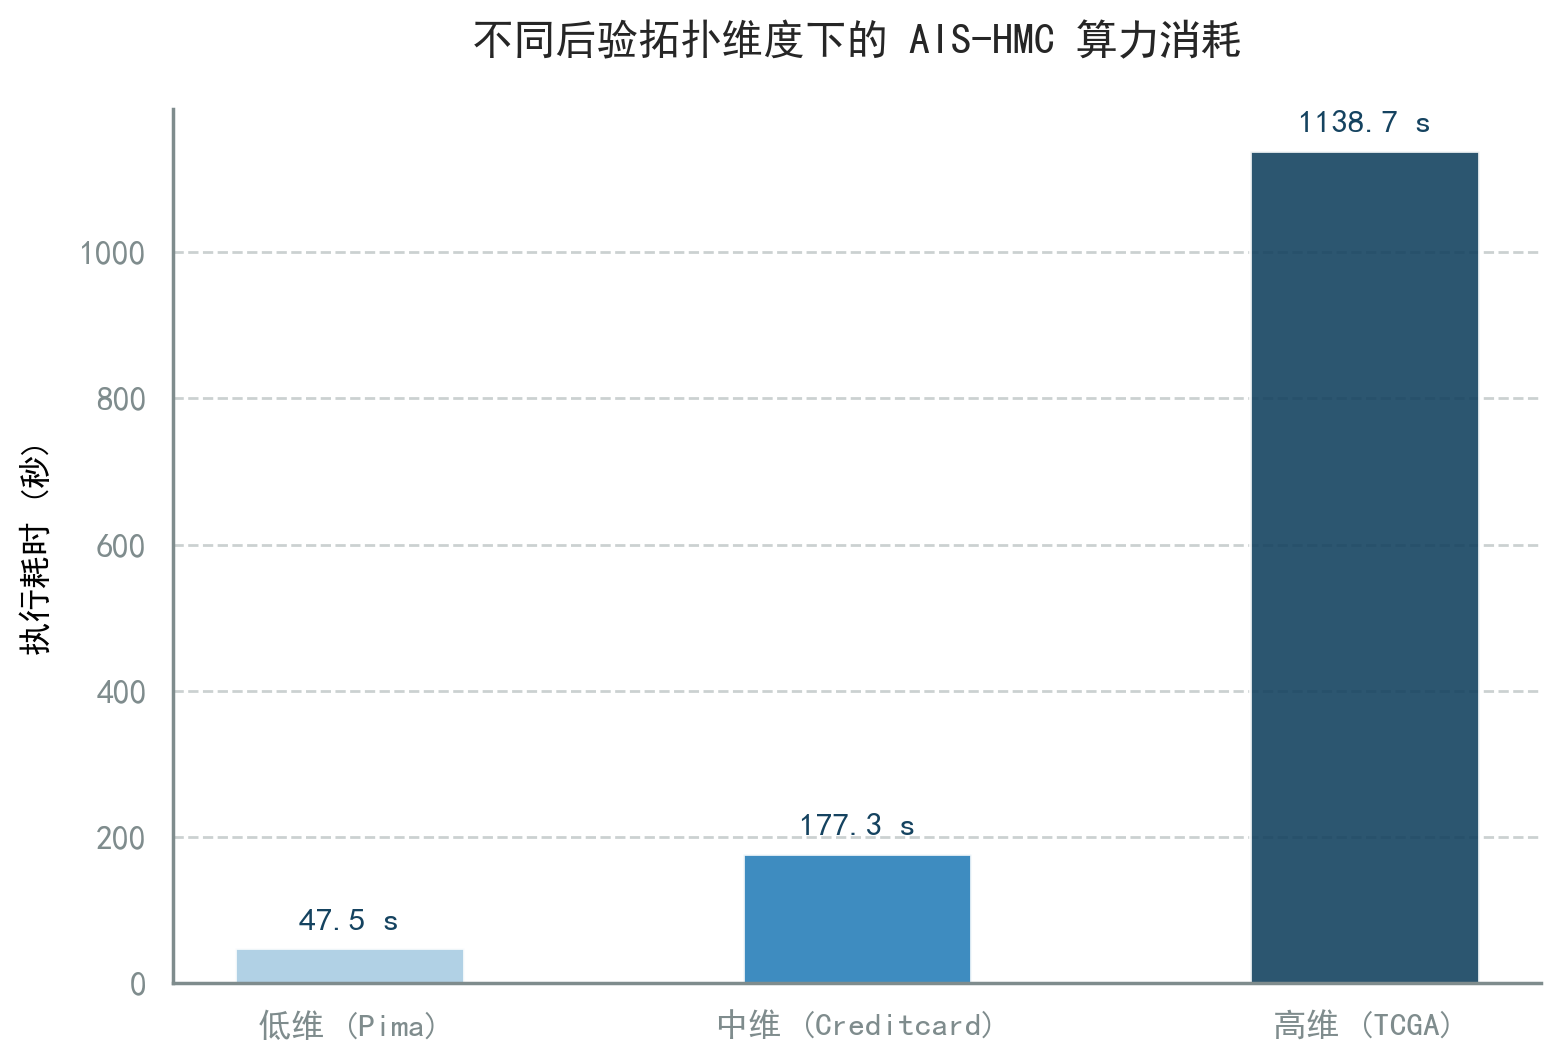

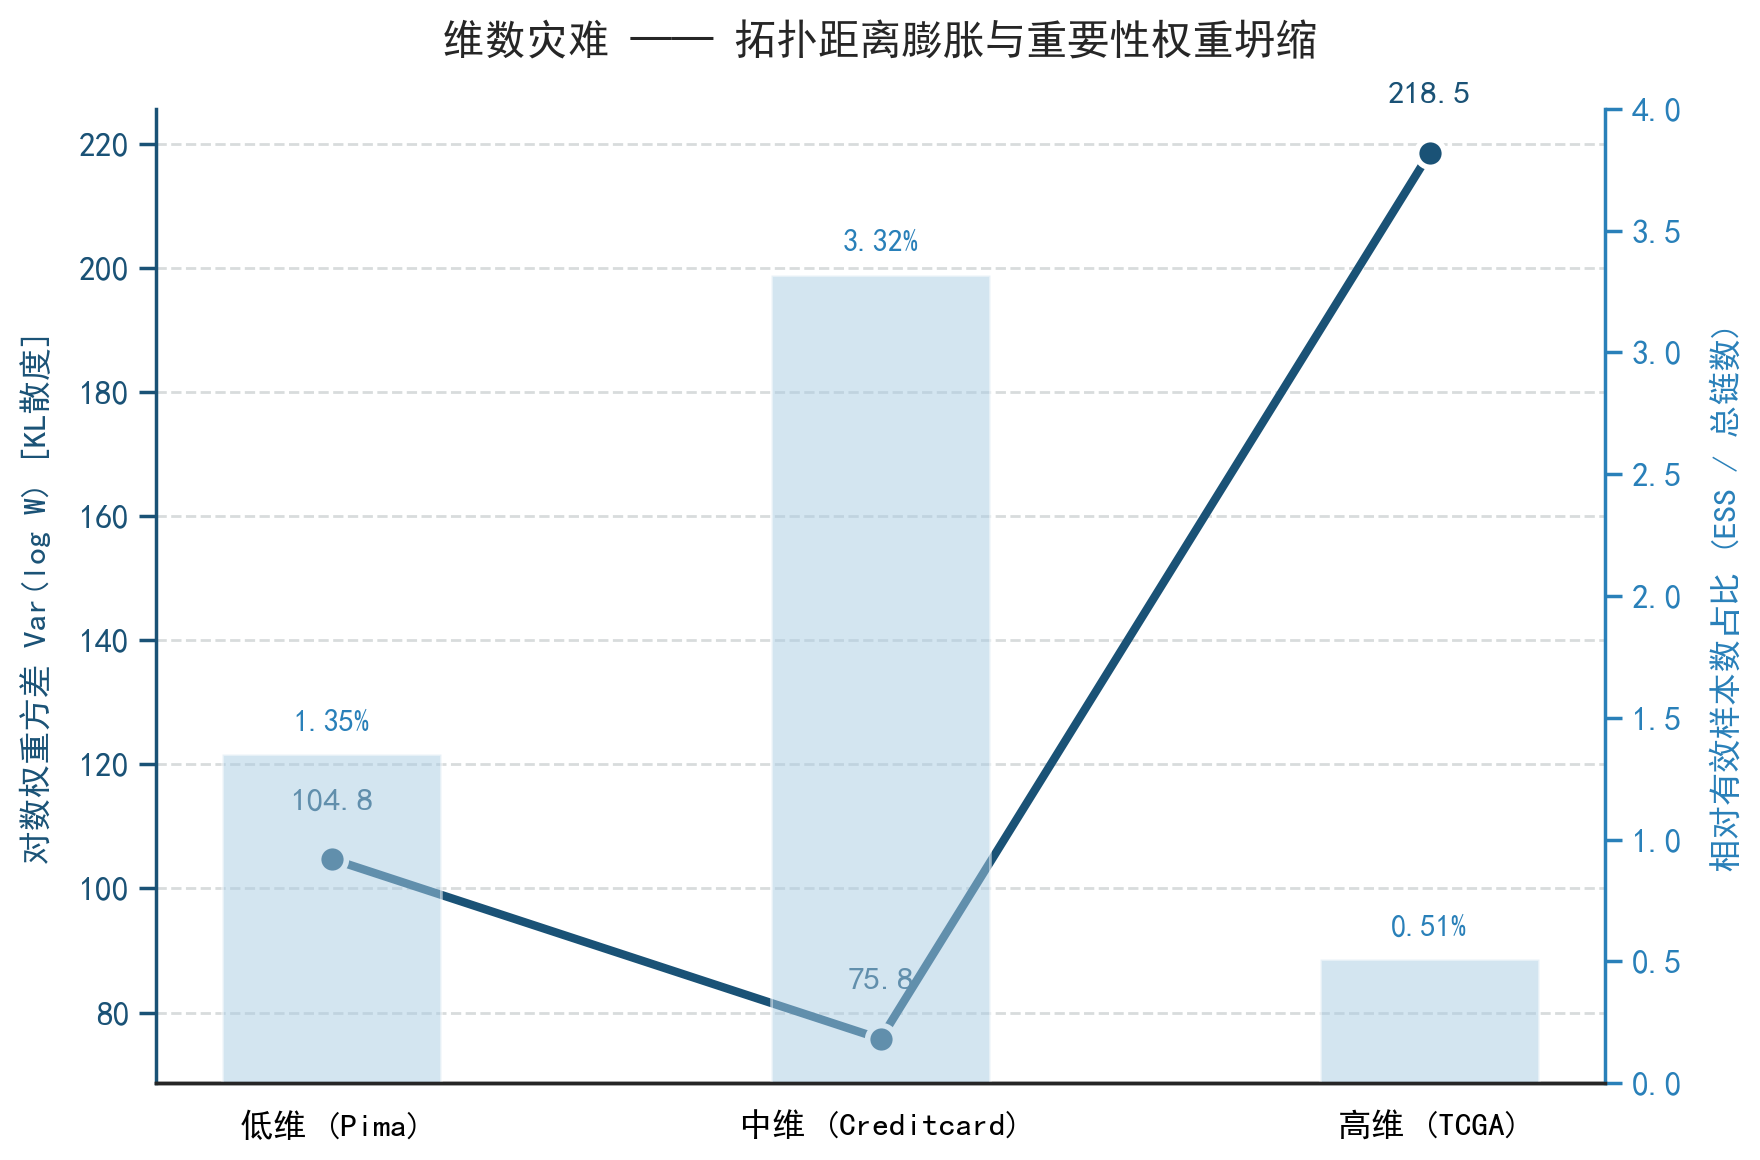

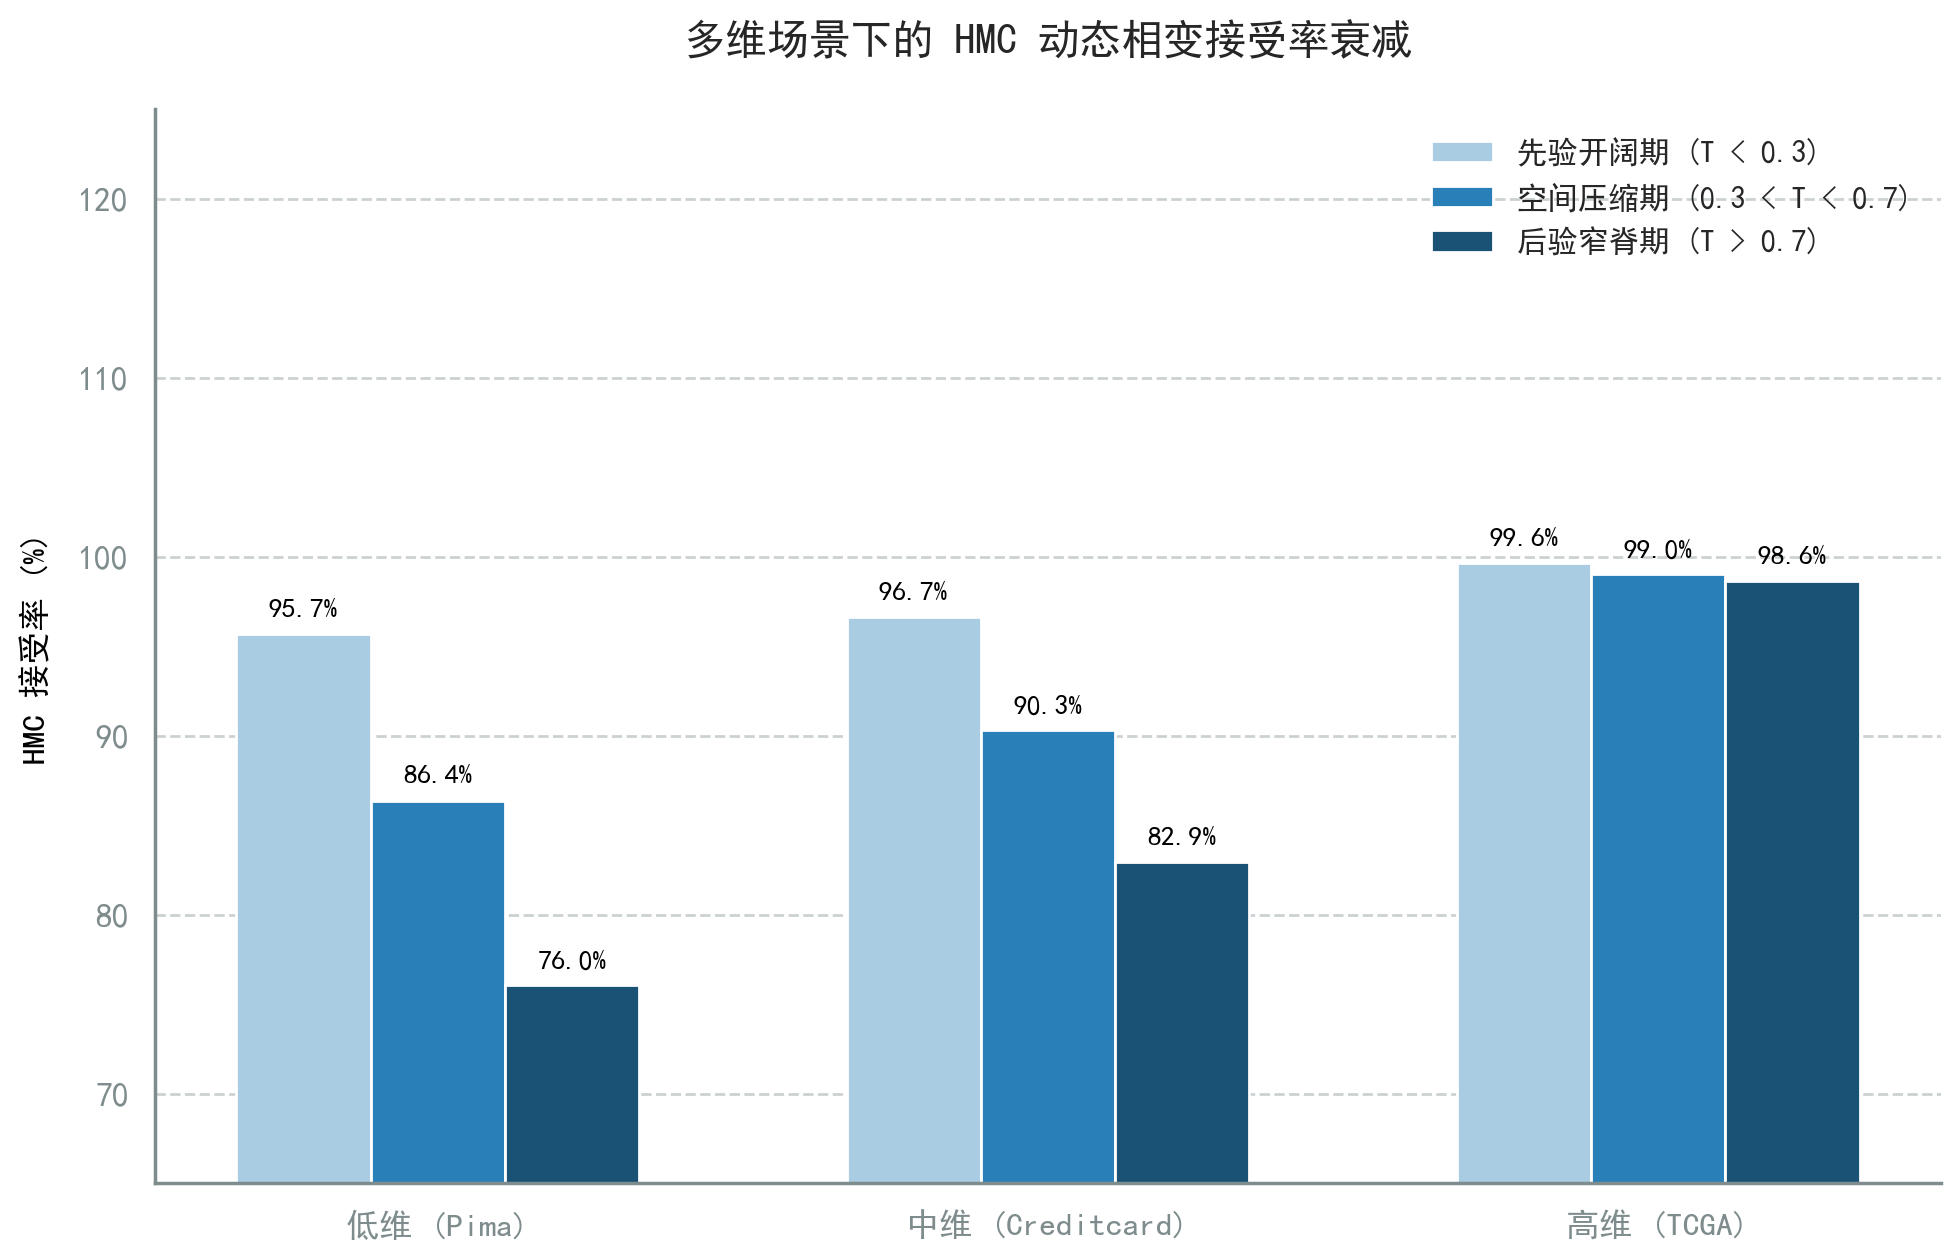

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="white", font_scale=1.1)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

C_LIGHT_BLUE = '#A9CCE3'  
C_MID_BLUE   = '#2980B9'   
C_DARK_BLUE  = '#1A5276'   
C_NAVY       = '#154360'  
C_GRAY       = '#7F8C8D'   

dimensions = ['低维 (Pima)', '中维 (Creditcard)', '高维 (TCGA)']
x_pos = np.arange(len(dimensions))

runtimes = [47.49, 177.29, 1138.74]
var_log_w = [104.75, 75.76, 218.52]
relative_ess_pct = [1.35, 3.32, 0.51]  

phase_1_acc = [95.70, 96.65, 99.64] 
phase_2_acc = [86.38, 90.32, 99.04] 
phase_3_acc = [76.05, 82.92, 98.64] 

def format_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(C_GRAY)
    ax.spines['bottom'].set_color(C_GRAY)
    ax.tick_params(colors=C_GRAY)
    ax.grid(axis='y', linestyle='--', alpha=0.4, color=C_GRAY)

def plot_runtime_explosion():
    fig, ax = plt.subplots(figsize=(8, 5.5), dpi=200)
    
    colors = [C_LIGHT_BLUE, C_MID_BLUE, C_NAVY]
    bars = ax.bar(x_pos, runtimes, color=colors, width=0.45, alpha=0.9, edgecolor='white')
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 20, f'{yval:.1f} s', 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color=C_NAVY)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(dimensions, fontsize=12, color='black')
    ax.set_ylabel('执行耗时 (秒)', fontsize=12, color='black', labelpad=10)
    ax.set_title('不同后验拓扑维度下的 AIS-HMC 算力消耗', fontsize=15, pad=20, fontweight='bold')
    
    format_spines(ax)
    plt.tight_layout()
    plt.show()

def plot_curse_of_dimensionality():
    fig, ax1 = plt.subplots(figsize=(9, 6), dpi=200)

    ax2 = ax1.twinx()
    bars = ax2.bar(x_pos, relative_ess_pct, color=C_LIGHT_BLUE, alpha=0.5, width=0.4, label='相对 ESS (%)')
    ax2.set_ylabel('相对有效样本数占比 (ESS / 总链数)', color=C_MID_BLUE, fontsize=12, labelpad=10)
    ax2.tick_params(axis='y', colors=C_MID_BLUE)
    ax2.set_ylim(0, 4.0)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_color(C_MID_BLUE)
    ax2.spines['left'].set_visible(False)

    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.08, f'{yval:.2f}%', 
                 ha='center', va='bottom', color=C_MID_BLUE, fontweight='bold', fontsize=11)

    ax1.plot(x_pos, var_log_w, color=C_DARK_BLUE, marker='o', markersize=10, 
             linewidth=3, markeredgecolor='white', markeredgewidth=2, label='Var(log W)')
    ax1.set_ylabel('对数权重方差 Var(log W) [KL散度]', color=C_DARK_BLUE, fontsize=12, labelpad=10)
    ax1.tick_params(axis='y', colors=C_DARK_BLUE)
    
    for i, v in enumerate(var_log_w):
        ax1.text(i, v + 8, f'{v:.1f}', ha='center', color=C_DARK_BLUE, fontweight='bold', fontsize=12)

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(dimensions, fontsize=12, color='black')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['left'].set_color(C_DARK_BLUE)
    ax1.grid(axis='y', linestyle='--', alpha=0.3, color=C_GRAY)

    plt.title('维数灾难 —— 拓扑距离膨胀与重要性权重坍缩', fontsize=15, pad=20, fontweight='bold')
    fig.tight_layout()
    plt.show()

def plot_acceptance_phase_decay():
    fig, ax = plt.subplots(figsize=(10, 6.5), dpi=200)
    width = 0.22
    
    bar1 = ax.bar(x_pos - width, phase_1_acc, width, label='先验开阔期 (T < 0.3)', color=C_LIGHT_BLUE)
    bar2 = ax.bar(x_pos,         phase_2_acc, width, label='空间压缩期 (0.3 < T < 0.7)', color=C_MID_BLUE)
    bar3 = ax.bar(x_pos + width, phase_3_acc, width, label='后验窄脊期 (T > 0.7)', color=C_DARK_BLUE)

    ax.set_ylabel('HMC 接受率 (%)', fontsize=12, color='black', labelpad=10)
    ax.set_title('多维场景下的 HMC 动态相变接受率衰减', fontsize=15, pad=20, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(dimensions, fontsize=12, color='black')
    ax.set_ylim(65, 125) 
    
    ax.legend(loc='upper right', frameon=False, fontsize=11)
    
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 5), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, color='black')

    add_labels(bar1)
    add_labels(bar2)
    add_labels(bar3)

    format_spines(ax)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_runtime_explosion()
    plot_curse_of_dimensionality()
    plot_acceptance_phase_decay()